# Деревья решений и ансамблевые методы классификации

Проект посвящён исследованию алгоритмов на основе деревьев решений - от реализации с нуля до сравнительного анализа современных ансамблевых методов.

**Основные разделы:**
1. Решающее дерево - реализация с нуля (критерий Джини, категориальные и вещественные признаки)
2. Random Forest - реализация с нуля
3. Сравнительный анализ: Decision Tree, Bagging, Random Forest, XGBoost, CatBoost, LightGBM
4. Выводы

**Данные:**
- [Mushroom Dataset](https://archive.ics.uci.edu/ml/datasets/Mushroom) (UCI) - классификация грибов на съедобные и ядовитые
- [BNP Paribas Cardif Claims Management](https://www.kaggle.com/c/bnp-paribas-cardif-claims-management) (Kaggle) - бинарная классификация страховых случаев

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from decision_tree import DecisionTree

## 1. Решающее дерево - реализация с нуля

Реализация (`decision_tree.py`) включает:
- Поиск оптимального разбиения по критерию Джини с **векторизованным** вычислением через кумулятивные суммы
- Поддержку вещественных и категориальных признаков (категориальные кодируются по доле положительного класса)
- Настраиваемые критерии останова: `max_depth`, `min_samples_split`, `min_samples_leaf`
- Вычисление **feature importances** (взвешенное снижение Gini impurity)

**Датасет:** [Mushroom](https://archive.ics.uci.edu/ml/datasets/Mushroom) (UCI) - 8124 объекта, 22 категориальных признака, бинарная классификация (съедобный / ядовитый).

In [2]:
df = pd.read_csv("agaricus-lepiota.csv")

encoder = LabelEncoder()
for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

target_col = "edible_or_poisonous"
X = df.drop(columns=[target_col])
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1101)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}, Features: {X_train.shape[1]}")

Train: 4062, Test: 4062, Features: 22


In [3]:
feature_types = ["categorical"] * X_train.shape[1]

tree = DecisionTree(feature_types=feature_types)
tree.fit(X_train.values, y_train)

y_pred = tree.predict(X_test.values)
print(f"Custom Decision Tree Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Custom Decision Tree Accuracy: 1.0000


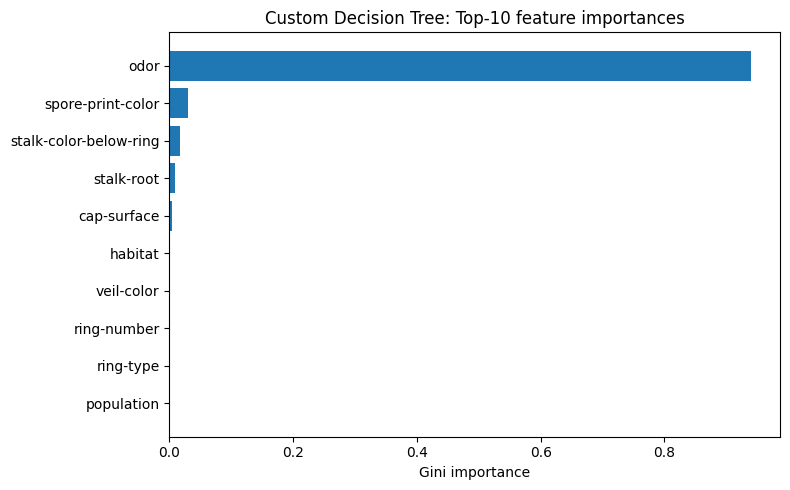

In [4]:
importances = tree.feature_importances_
top_idx = np.argsort(importances)[-10:]

plt.figure(figsize=(8, 5))
plt.barh(range(len(top_idx)), importances[top_idx])
plt.yticks(range(len(top_idx)), X.columns[top_idx])
plt.xlabel("Gini importance")
plt.title("Custom Decision Tree: Top-10 feature importances")
plt.tight_layout()
plt.show()

Визуализация верхних уровней построенного дерева (до глубины 4):

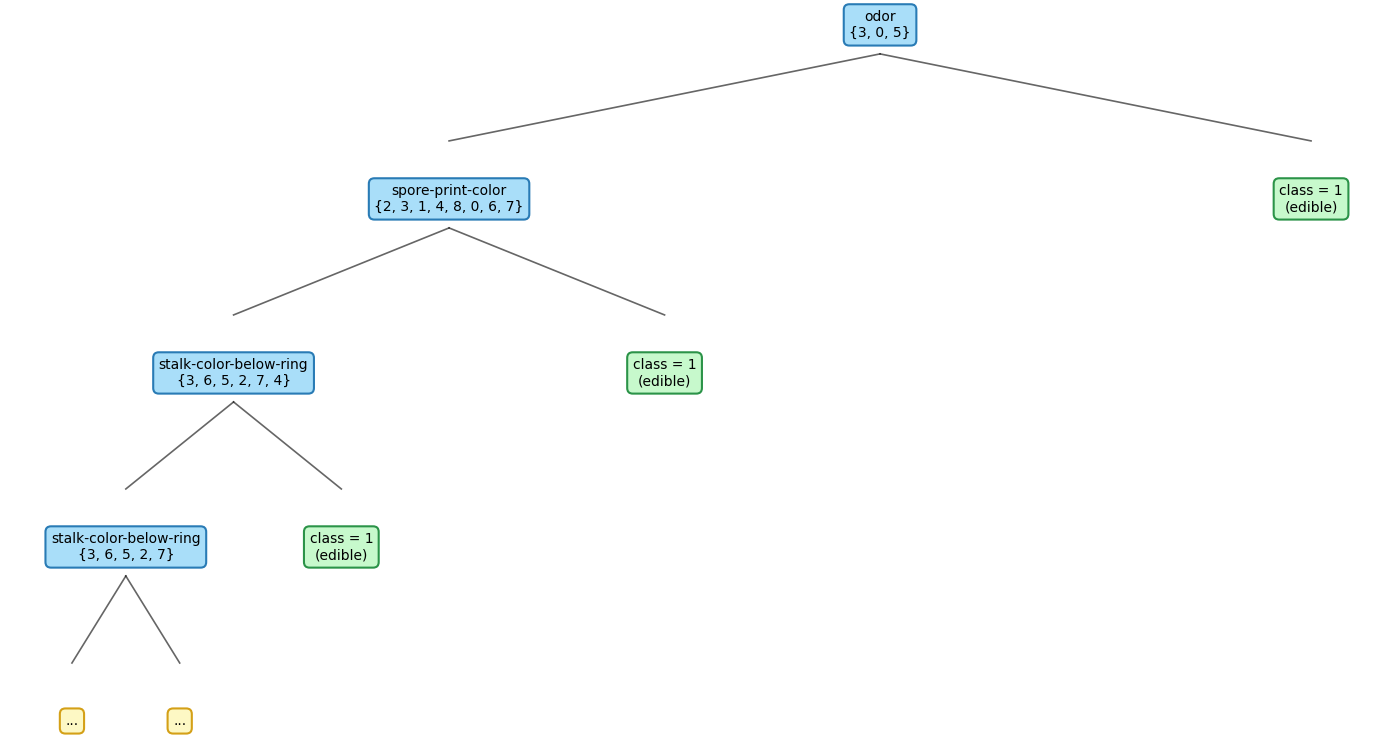

In [5]:
def plot_tree(tree_dict, feature_names, class_names=None, max_depth=3, figsize=(12, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    y_start = 0.9
    y_step = 0.18
    COLORS = {"leaf": "#c7f9cc", "node": "#a9def9", "subtree": "#fdf8c4"}

    def format_leaf(node):
        cls = node["class"]
        if class_names and cls in class_names:
            return f"class = {cls}\n({class_names[cls]})"
        return f"class = {cls}"

    def format_node(node):
        idx = node["feature_split"]
        name = str(feature_names[idx])
        if "threshold" in node:
            return f"{name}\n< {node['threshold']:.3f}"
        cats = node.get("categories_split", [])
        cats_str = ", ".join(map(str, cats))
        if len(cats_str) > 30:
            cats_str = cats_str[:27] + "..."
        return f"{name}\n{{{cats_str}}}"

    def draw(node, x, y, x_min, x_max, depth):
        if node["type"] == "terminal":
            ax.text(x, y, format_leaf(node), ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.4", fc=COLORS["leaf"], ec="#2b9348", lw=1.5))
            return
        if depth >= max_depth:
            ax.text(x, y, "...", ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.4", fc=COLORS["subtree"], ec="#d4a017", lw=1.5))
            return
        ax.text(x, y, format_node(node), ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.4", fc=COLORS["node"], ec="#297bb5", lw=1.5))
        child_y = y - y_step
        mid = (x_min + x_max) / 2
        for child_key, cx, bnd in [("left_child", (x_min + mid) / 2, (x_min, mid)),
                                    ("right_child", (mid + x_max) / 2, (mid, x_max))]:
            ax.plot([x, cx], [y - 0.03, child_y + 0.06], color="black", alpha=0.6, lw=1.2)
            draw(node[child_key], cx, child_y, *bnd, depth + 1)

    draw(tree_dict, 0.5, y_start, 0.0, 1.0, 0)
    plt.tight_layout()
    plt.show()


class_names = {0: "poisonous", 1: "edible"}
plot_tree(tree._tree, feature_names=X.columns, class_names=class_names, max_depth=4, figsize=(14, 7))

## 2. Random Forest - реализация с нуля

Реализация на базе `DecisionTreeClassifier` из sklearn с ключевыми элементами алгоритма:
- **Бутстрап-выборки** - обучение каждого дерева на случайной подвыборке с возвращением
- **Случайное подпространство признаков** - каждое дерево обучается на `max_features` случайно выбранных признаках
- **Агрегация предсказаний** - усреднение вероятностей по всем деревьям с выравниванием классов

Класс наследуется от `BaseEstimator` и реализует интерфейс, совместимый со sklearn (`fit`, `predict`, `predict_proba`).

In [6]:
class RandomForestClassifierCustom(BaseEstimator):
    def __init__(self, n_estimators=100, max_depth=None, max_features=None, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.feat_ids_by_tree = []

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.class_to_idx_ = {cls: i for i, cls in enumerate(self.classes_)}

        max_feat = self.max_features or n_features
        self.trees, self.feat_ids_by_tree = [], []

        for i in range(self.n_estimators):
            np.random.seed(self.random_state + i)
            feat_ids = np.random.choice(n_features, size=max_feat, replace=False)
            sample_ids = np.random.choice(n_samples, size=n_samples, replace=True)

            dt = DecisionTreeClassifier(
                max_depth=self.max_depth,
                max_features=self.max_features,
                random_state=self.random_state,
            )
            dt.fit(X[sample_ids][:, feat_ids], y[sample_ids])
            self.trees.append(dt)
            self.feat_ids_by_tree.append(feat_ids)

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        proba_sum = np.zeros((X.shape[0], self.n_classes_))

        for dt, feat_ids in zip(self.trees, self.feat_ids_by_tree):
            tree_proba = dt.predict_proba(X[:, feat_ids])
            aligned = np.zeros_like(proba_sum)
            for j, cls in enumerate(dt.classes_):
                aligned[:, self.class_to_idx_[cls]] = tree_proba[:, j]
            proba_sum += aligned

        return proba_sum / len(self.trees)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

In [7]:
rf_custom = RandomForestClassifierCustom(
    n_estimators=500,
    max_depth=10,
    max_features=int(np.sqrt(X_train.shape[1])),
    random_state=1101,
)
rf_custom.fit(X_train, y_train)

y_pred = rf_custom.predict(X_test)
print(f"Custom Random Forest Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Custom Random Forest Accuracy: 0.9983


## 3. Сравнительный анализ ансамблевых методов

Для сравнения используется датасет [BNP Paribas Cardif Claims Management](https://www.kaggle.com/c/bnp-paribas-cardif-claims-management) - задача бинарной классификации страховых случаев. Из первых 10 000 объектов оставлены только вещественные признаки, пропуски заполнены нулями. Разбиение: 70% обучение, 30% тест.

In [8]:
ds = pd.read_csv("train.csv", index_col=0).iloc[:10_000]

target = "target"
X = ds.select_dtypes(include=["float"]).fillna(0)
y = ds[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1101)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (7000, 108), Test: (3000, 108)


### 3.1 Базовые модели: дерево, бэггинг, Random Forest

Оценка качества с помощью 3-fold кросс-валидации на обучающей выборке:

In [9]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=1101),
    "Bagging (100 trees)": BaggingClassifier(
        estimator=DecisionTreeClassifier(), n_estimators=100, random_state=1101
    ),
    "Random Forest (100 trees)": RandomForestClassifier(
        n_estimators=100, random_state=1101, n_jobs=-1
    ),
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
    print(f"{name:30s} CV accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

Decision Tree                  CV accuracy: 0.6540 (+/- 0.0037)
Bagging (100 trees)            CV accuracy: 0.7454 (+/- 0.0077)
Random Forest (100 trees)      CV accuracy: 0.7464 (+/- 0.0069)


### 3.2 Зависимость качества от числа деревьев

Исследуем, переобучается ли Random Forest при увеличении числа деревьев. Используем `warm_start=True` для инкрементального добавления деревьев без повторного обучения уже построенных:

Best: 180 trees, accuracy: 0.7537


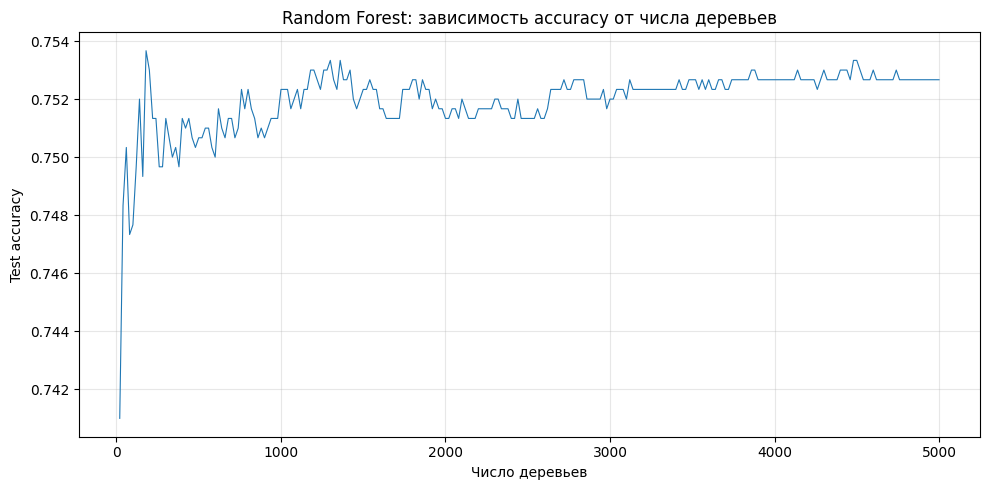

In [10]:
n_estimators_range = list(range(20, 5001, 20))

rf = RandomForestClassifier(
    n_estimators=0, random_state=1101, n_jobs=-1, warm_start=True
)

test_scores = []
for n in n_estimators_range:
    rf.set_params(n_estimators=n)
    rf.fit(X_train, y_train)
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

best_idx = np.argmax(test_scores)
print(f"Best: {n_estimators_range[best_idx]} trees, accuracy: {test_scores[best_idx]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_range, test_scores, linewidth=0.8)
plt.xlabel("Число деревьев")
plt.ylabel("Test accuracy")
plt.title("Random Forest: зависимость accuracy от числа деревьев")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

При увеличении числа деревьев Random Forest **не переобучается** - качество быстро выходит на плато. Это объясняется тем, что количество деревьев влияет на дисперсию ансамбля, а не на смещение. Дополнительные деревья лишь стабилизируют результат.

### 3.3 Градиентный бустинг: XGBoost, CatBoost, LightGBM

Подбор гиперпараметров для каждой реализации с помощью `RandomizedSearchCV`:

In [11]:
xgb = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    n_estimators=500, random_state=1101, tree_method="hist", n_jobs=-1,
)

param_dist_xgb = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1101)

rs_xgb = RandomizedSearchCV(
    xgb, param_dist_xgb, n_iter=30, scoring="accuracy",
    cv=cv, n_jobs=-1, verbose=1, random_state=1101,
)
rs_xgb.fit(X_train, y_train)

best_xgb = rs_xgb.best_estimator_
print(f"XGBoost best params: {rs_xgb.best_params_}")
print(f"XGBoost CV accuracy: {rs_xgb.best_score_:.4f}")
print(f"XGBoost test accuracy: {accuracy_score(y_test, best_xgb.predict(X_test)):.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
XGBoost best params: {'subsample': 0.6, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
XGBoost CV accuracy: 0.7646
XGBoost test accuracy: 0.7677


In [14]:
cb = CatBoostClassifier(
    loss_function="Logloss", eval_metric="Accuracy",
    verbose=False, random_state=1101, thread_count=-1,
)

param_dist_cb = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations": [300, 500, 800],
    "l2_leaf_reg": [1, 3, 5, 7],
}

rs_cb = RandomizedSearchCV(
    cb, param_dist_cb, n_iter=20, scoring="accuracy",
    cv=cv, n_jobs=-1, verbose=1, random_state=1101,
)
rs_cb.fit(X_train, y_train)

best_cb = rs_cb.best_estimator_
print(f"CatBoost best params: {rs_cb.best_params_}")
print(f"CatBoost CV accuracy: {rs_cb.best_score_:.4f}")
print(f"CatBoost test accuracy: {accuracy_score(y_test, best_cb.predict(X_test)):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
CatBoost best params: {'learning_rate': 0.03, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 6}
CatBoost CV accuracy: 0.7636
CatBoost test accuracy: 0.7643


In [15]:
lgbm = LGBMClassifier(objective="binary", random_state=1101, n_jobs=-1, verbose=-1)

param_dist_lgbm = {
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [300, 500, 800],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_samples": [10, 20, 30],
}

rs_lgbm = RandomizedSearchCV(
    lgbm, param_dist_lgbm, n_iter=25, scoring="accuracy",
    cv=cv, n_jobs=-1, verbose=1, random_state=1101,
)
rs_lgbm.fit(X_train, y_train)

best_lgbm = rs_lgbm.best_estimator_
print(f"LightGBM best params: {rs_lgbm.best_params_}")
print(f"LightGBM CV accuracy: {rs_lgbm.best_score_:.4f}")
print(f"LightGBM test accuracy: {accuracy_score(y_test, best_lgbm.predict(X_test)):.4f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
LightGBM best params: {'subsample': 0.6, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 30, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
LightGBM CV accuracy: 0.7617
LightGBM test accuracy: 0.7657


Все три реализации градиентного бустинга показывают близкие результаты, уверенно превосходя Random Forest. Разница между XGBoost, CatBoost и LightGBM находится в пределах статистического шума - ощутимого преимущества одной конкретной библиотеки не наблюдается.

In [16]:
results = {
    "Random Forest": accuracy_score(y_test, rf.predict(X_test)),
    "XGBoost": accuracy_score(y_test, best_xgb.predict(X_test)),
    "CatBoost": accuracy_score(y_test, best_cb.predict(X_test)),
    "LightGBM": accuracy_score(y_test, best_lgbm.predict(X_test)),
}

comparison = pd.DataFrame.from_dict(results, orient="index", columns=["Test Accuracy"])
comparison = comparison.sort_values("Test Accuracy", ascending=False)
comparison.style.format("{:.4f}").bar(color="#a9def9", vmin=0.7, vmax=0.8)

,Test Accuracy
XGBoost,0.7677
LightGBM,0.7657
CatBoost,0.7643
Random Forest,0.7527


### 3.4 Анализ важности признаков

Сравнение Top-20 признаков по важности для каждой модели:

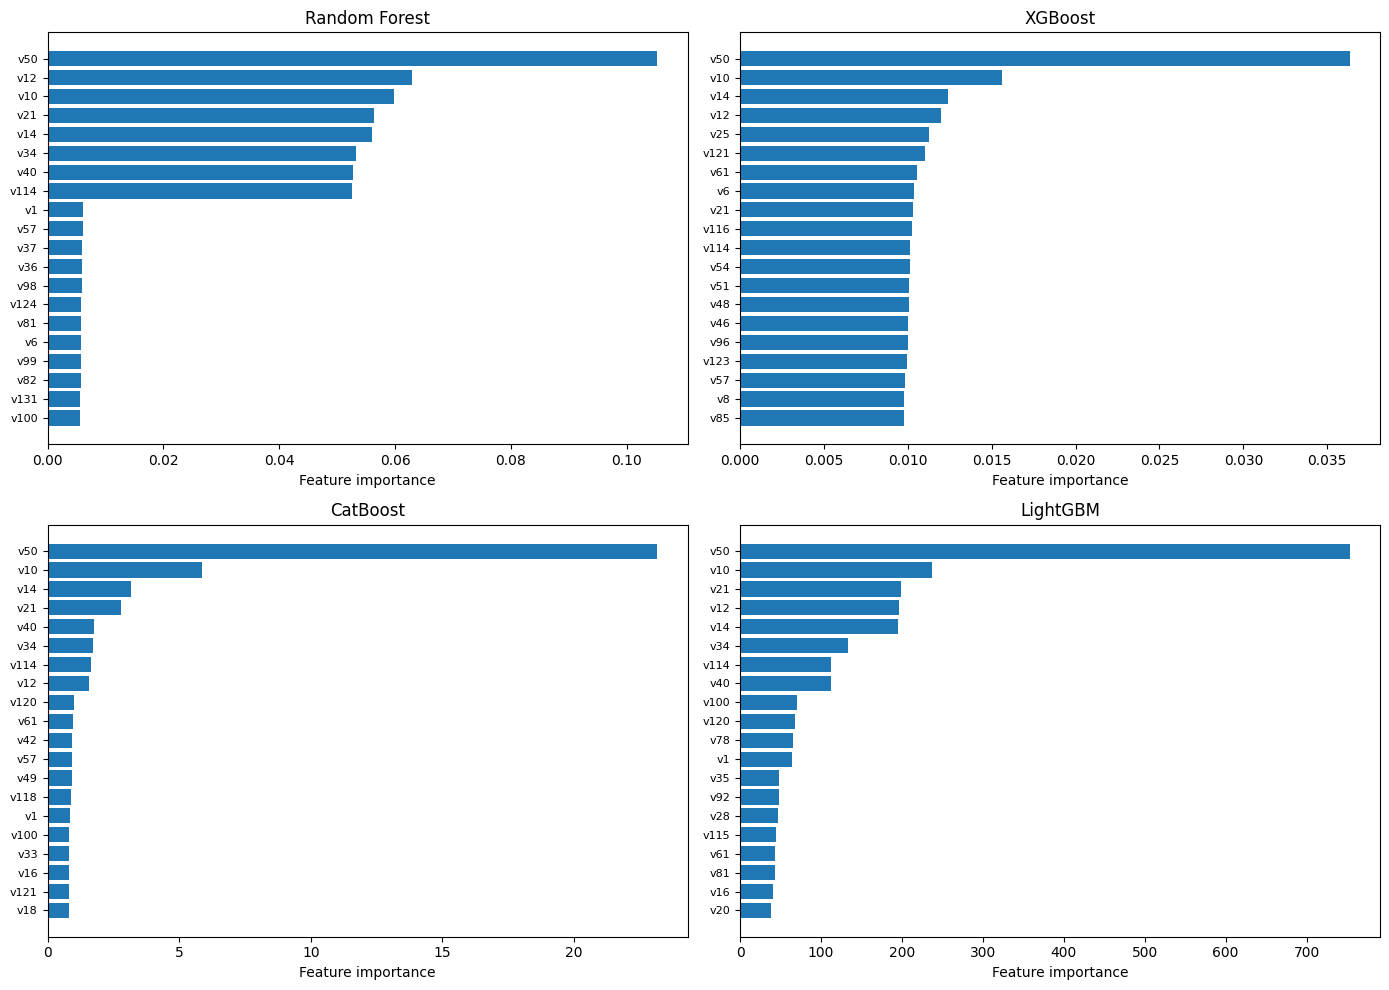

In [17]:
model_importances = {
    "Random Forest": rf.feature_importances_,
    "XGBoost": best_xgb.feature_importances_,
    "CatBoost": best_cb.feature_importances_,
    "LightGBM": best_lgbm.feature_importances_,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, imps) in zip(axes.ravel(), model_importances.items()):
    idx = np.argsort(imps)[-20:]
    ax.barh(range(len(idx)), imps[idx])
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels(X_train.columns[idx], fontsize=8)
    ax.set_xlabel("Feature importance")
    ax.set_title(name)

plt.tight_layout()
plt.show()

Уникальных признаков в объединённом Top-20: 45


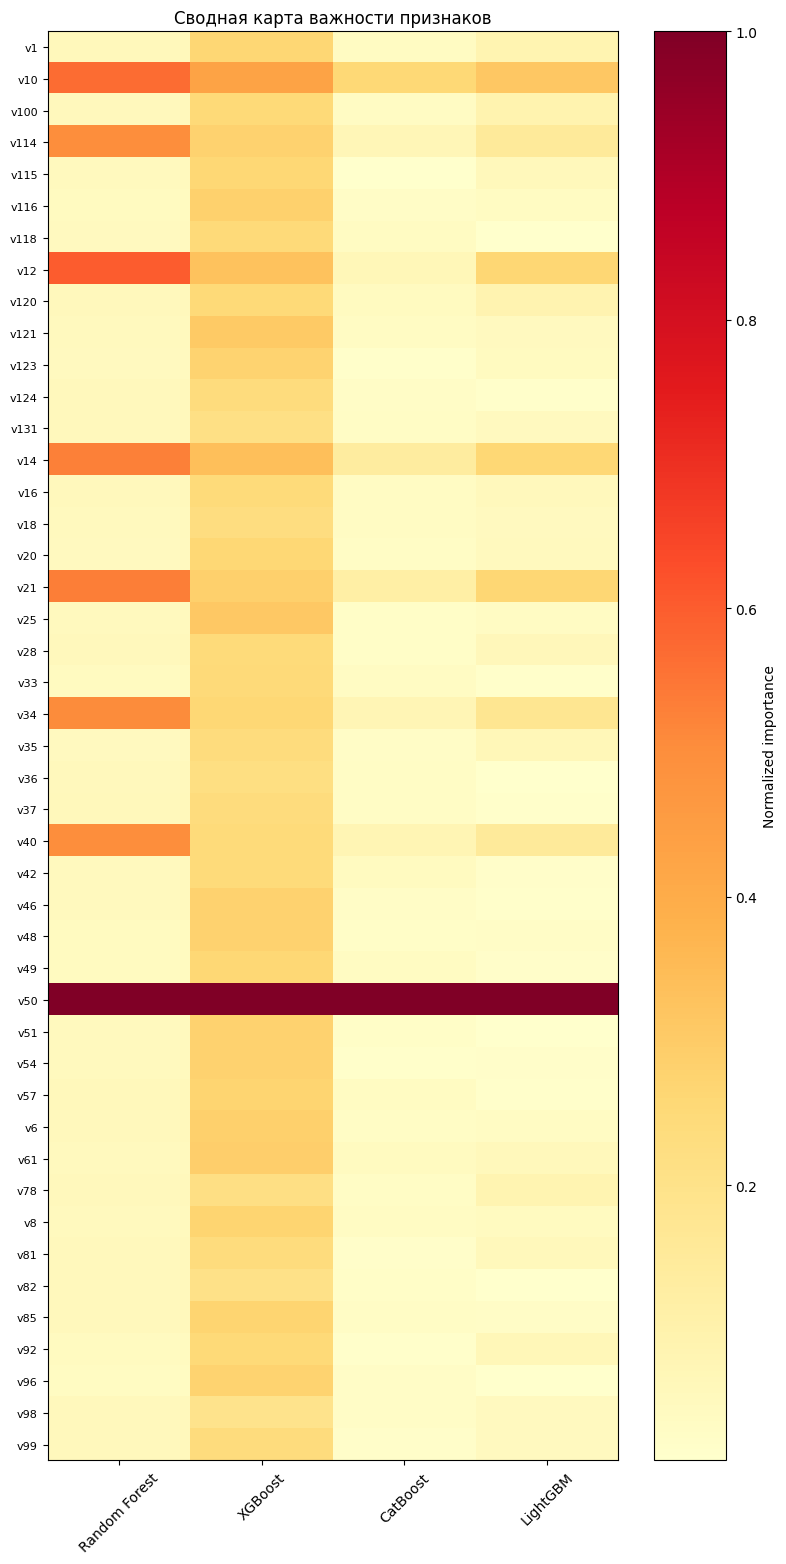

In [18]:
all_top20 = set()
for imps in model_importances.values():
    idx = np.argsort(imps)[-20:]
    all_top20.update(X_train.columns[idx])

top_features = sorted(all_top20)
print(f"Уникальных признаков в объединённом Top-20: {len(top_features)}")

heatmap_data = pd.DataFrame(index=top_features)
for name, imps in model_importances.items():
    s = pd.Series(imps, index=X_train.columns)
    heatmap_data[name] = s.loc[top_features]

heatmap_norm = heatmap_data / heatmap_data.max()

plt.figure(figsize=(8, max(4, 0.35 * len(top_features))))
plt.imshow(heatmap_norm.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Normalized importance")
plt.yticks(range(len(top_features)), heatmap_norm.index, fontsize=8)
plt.xticks(range(len(heatmap_norm.columns)), heatmap_norm.columns, rotation=45)
plt.title("Сводная карта важности признаков")
plt.tight_layout()
plt.show()

Все четыре модели выделяют устойчивое ядро ключевых признаков, подтверждая их реальную предсказательную силу. Random Forest распределяет важность более равномерно, подхватывая больше слабых сигналов. Градиентный бустинг концентрирует вес на меньшем числе наиболее информативных признаков, что характерно для последовательного построения деревьев.

### 3.5 Влияние способа кодирования категориальных признаков

Сравнение трёх подходов к кодированию категориальных признаков (с числом уникальных значений < 50):
- **One-Hot Encoding** - бинарные столбцы для каждого значения
- **Label Encoding** - порядковая нумерация (порядок произвольный)
- **Target Encoding** со сглаживанием ($\alpha = 10$) - замена категорий сглаженным средним значением целевой переменной

In [19]:
X_num = ds.select_dtypes(include=["float"]).fillna(0)
y_full = ds[target].values

cat_cols = [
    c for c in ds.select_dtypes(include=["object", "category"]).columns
    if ds[c].nunique() < 50
]
print(f"Категориальные признаки: {cat_cols}")


def run_random_search(X_data, y_data, name, n_iter=40):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_data, y_data, test_size=0.2, random_state=1101, stratify=y_data
    )
    param_dist = {
        "max_depth": list(range(2, 21)),
        "min_samples_split": list(range(2, 21)),
        "min_samples_leaf": list(range(1, 21)),
    }
    rs = RandomizedSearchCV(
        DecisionTreeClassifier(random_state=1101),
        param_dist, n_iter=n_iter, cv=3,
        scoring="accuracy", n_jobs=-1, random_state=1101,
    )
    rs.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, rs.predict(X_te))
    print(f"=== {name} ===")
    print(f"Best params: {rs.best_params_}")
    print(f"CV accuracy: {rs.best_score_:.4f}, Test accuracy: {acc:.4f}")
    return rs.best_params_, acc


X_ohe = pd.concat(
    [X_num, pd.get_dummies(ds[cat_cols].fillna("NA"), drop_first=False)], axis=1
)
run_random_search(X_ohe, y_full, "One-Hot Encoding")

X_ord = X_num.copy()
for c in cat_cols:
    X_ord[c] = LabelEncoder().fit_transform(ds[c].fillna("NA"))
run_random_search(X_ord, y_full, "Label Encoding")

alpha = 10
global_mean = y_full.mean()
X_target_enc = X_num.copy()
for c in cat_cols:
    stats = ds.groupby(c)[target].agg(["mean", "count"])
    stats["smoothed"] = (
        (stats["mean"] * stats["count"] + global_mean * alpha) / (stats["count"] + alpha)
    )
    X_target_enc[c] = ds[c].map(stats["smoothed"])
run_random_search(X_target_enc, y_full, "Target Encoding (alpha=10)")

Категориальные признаки: ['v3', 'v24', 'v30', 'v31', 'v47', 'v52', 'v66', 'v71', 'v74', 'v75', 'v79', 'v91', 'v107', 'v110', 'v112', 'v113']
=== One-Hot Encoding ===
Best params: {'min_samples_split': 12, 'min_samples_leaf': 1, 'max_depth': 4}
CV accuracy: 0.7689, Test accuracy: 0.7775
=== Label Encoding ===
Best params: {'min_samples_split': 12, 'min_samples_leaf': 1, 'max_depth': 4}
CV accuracy: 0.7655, Test accuracy: 0.7775
=== Target Encoding (alpha=10) ===
Best params: {'min_samples_split': 15, 'min_samples_leaf': 18, 'max_depth': 3}
CV accuracy: 0.7640, Test accuracy: 0.7745


({'min_samples_split': 15, 'min_samples_leaf': 18, 'max_depth': 3}, 0.7745)

Способ кодирования влияет на оптимальную глубину дерева: target encoding создаёт более информативные признаки, позволяя дереву достигать сопоставимого качества при меньшей глубине. OHE увеличивает размерность и требует больше времени на обучение, но даёт полную информацию о каждой категории без привнесения ложного порядка. Label Encoding - самый быстрый, но порядковая нумерация может вводить ложные зависимости для моделей, чувствительных к порядку.

## 4. Выводы

**Реализация с нуля:**
- Решающее дерево с критерием Джини достигает accuracy $\approx$ 1.0 на Mushroom Dataset, что подтверждает корректность реализации
- Собственный Random Forest на базе sklearn `DecisionTreeClassifier` показывает результаты, сопоставимые с `RandomForestClassifier`

**Сравнительный анализ ансамблевых методов:**
- Ансамблевые методы стабильно превосходят одиночное дерево решений; качество растёт от Decision Tree к Bagging и далее к Random Forest
- Random Forest не переобучается при увеличении числа деревьев - качество выходит на плато
- XGBoost, CatBoost и LightGBM показывают близкие результаты, все три превосходят Random Forest
- Анализ feature importances выявляет устойчивое ядро ключевых признаков, согласованных между всеми четырьмя моделями
- Target encoding позволяет использовать менее глубокие деревья при сохранении качества предсказания